In [ ]:
from google.colab import files
uploaded = files.upload()

Saving order_history_kaggle_data.csv to order_history_kaggle_data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('order_history_kaggle_data.csv')

print("Shape:", df.shape)
df.head()

Shape: (21321, 29)


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [ ]:
# Column names clean
df.columns = df.columns.str.strip()

# Total Discount column banao (sab discounts ka sum)
df['Total_Discount'] = (
    df['Restaurant discount (Promo)'].fillna(0) +
    df['Restaurant discount (Flat offs, Freebies & others)'].fillna(0) +
    df['Gold discount'].fillna(0) +
    df['Brand pack discount'].fillna(0)
)

# Date column fix
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
df['Month'] = df['Order Placed At'].dt.month
df['Day'] = df['Order Placed At'].dt.day_name()
df['Hour'] = df['Order Placed At'].dt.hour

# Distance ko numeric banao
df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

print("✅ Data Cleaned Successfully!")
print(f"Date Range: {df['Order Placed At'].min()} to {df['Order Placed At'].max()}")
print(f"Total Records: {len(df):,}")
print(f"Total Restaurants: {df['Restaurant name'].nunique()}")
print(f"\nMissing Values:\n{df[['Total', 'Rating', 'Total_Discount', 'KPT duration (minutes)']].isnull().sum()}")

✅ Data Cleaned Successfully!
Date Range: 2024-09-01 00:13:00 to 2025-01-31 23:59:00
Total Records: 21,321
Total Restaurants: 6

Missing Values:
Total                         0
Rating                    18830
Total_Discount                0
KPT duration (minutes)      295
dtype: int64


📊 TOP 15 STORES BY REVENUE
                      Total_Revenue  Total_Orders  Avg_Order_Value  Avg_Rating
Restaurant name                                                               
Aura Pizzas             10751617.42         14548           739.04        4.32
Swaad                    3545521.86          6332           559.94        4.43
Tandoori Junction         133665.95           154           867.96        4.65
Dilli Burger Adda         101709.62           227           448.06        4.18
The Chicken Junction       12380.99            32           386.91        4.69
Masala Junction             9162.30            28           327.22        4.83


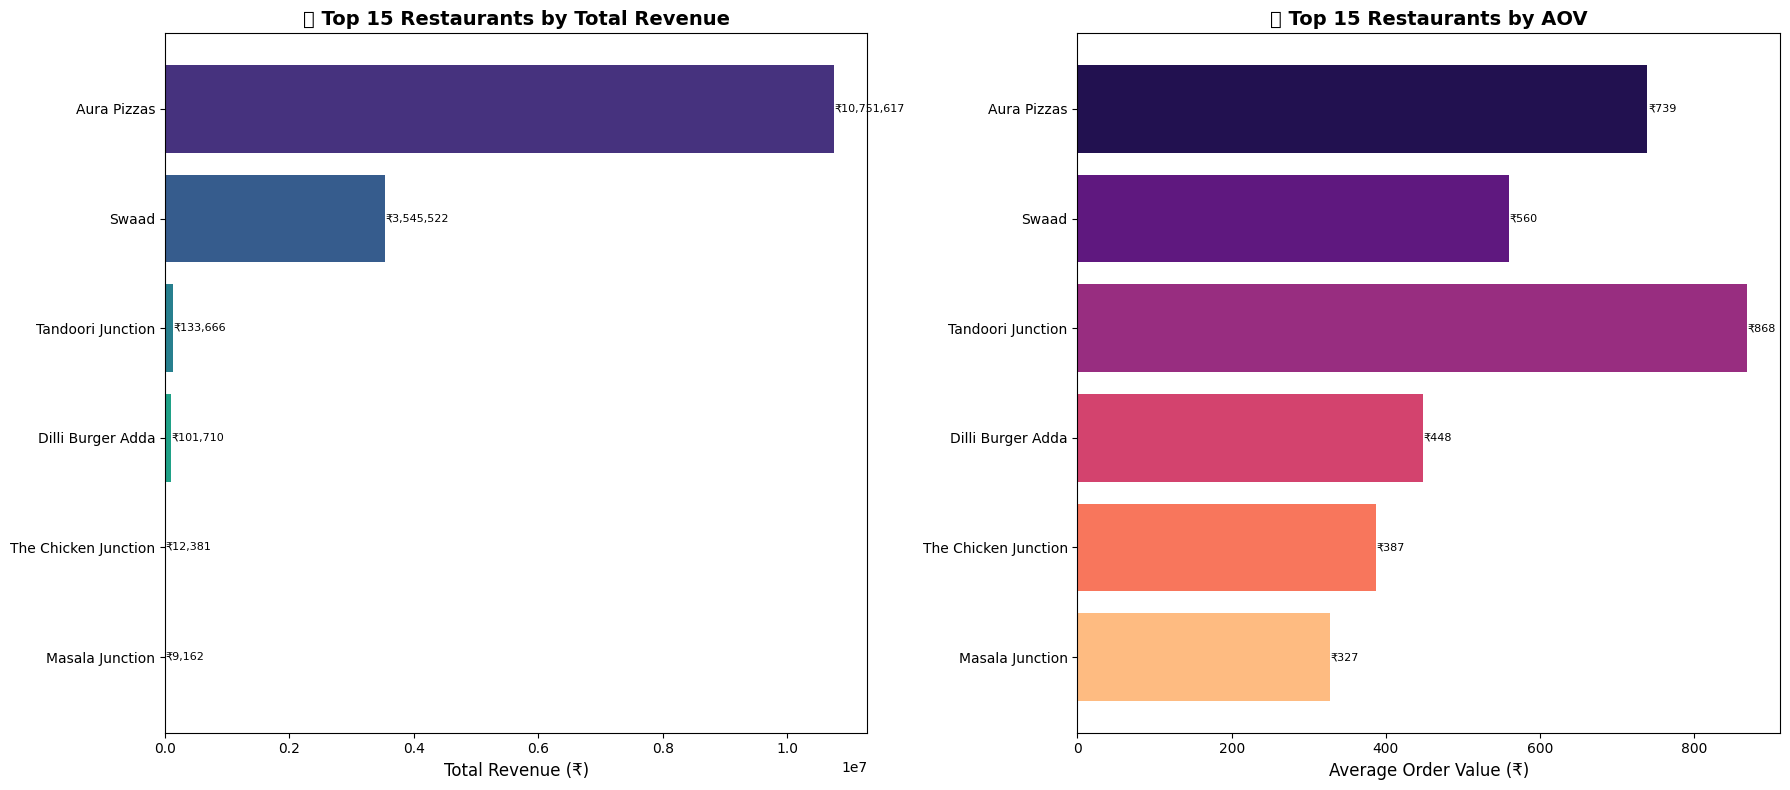

In [ ]:
# ============================
# 1. STORE-LEVEL REVENUE ANALYSIS
# ============================

revenue_by_store = df.groupby('Restaurant name').agg(
    Total_Revenue = ('Total', 'sum'),
    Total_Orders = ('Order ID', 'count'),
    Avg_Order_Value = ('Total', 'mean'),
    Avg_Rating = ('Rating', 'mean')
).sort_values('Total_Revenue', ascending=False).round(2)

# Top 15 stores lo (zyada hain toh chart readable nahi hoga)
top_stores = revenue_by_store.head(15)

print("="*60)
print("📊 TOP 15 STORES BY REVENUE")
print("="*60)
print(top_stores)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Revenue Bar Chart
colors = sns.color_palette("viridis", len(top_stores))
axes[0].barh(top_stores.index, top_stores['Total_Revenue'], color=colors)
axes[0].set_xlabel('Total Revenue (₹)', fontsize=12)
axes[0].set_title('🏪 Top 15 Restaurants by Total Revenue', fontsize=14, fontweight='bold')
for i, v in enumerate(top_stores['Total_Revenue']):
    axes[0].text(v + 500, i, f'₹{v:,.0f}', va='center', fontsize=8)
axes[0].invert_yaxis()

# AOV Chart
axes[1].barh(top_stores.index, top_stores['Avg_Order_Value'], color=sns.color_palette("magma", len(top_stores)))
axes[1].set_xlabel('Average Order Value (₹)', fontsize=12)
axes[1].set_title('💰 Top 15 Restaurants by AOV', fontsize=14, fontweight='bold')
for i, v in enumerate(top_stores['Avg_Order_Value']):
    axes[1].text(v + 1, i, f'₹{v:,.0f}', va='center', fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('store_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

🏷️ DISCOUNT IMPACT ANALYSIS
               Order_Count  Avg_Order_Value  Avg_Bill_Subtotal  Avg_Rating  \
Discount_Flag                                                                
Discounted           13029           664.97             796.96        4.31   
No Discount           8292           710.35             676.41        4.43   

               Total_Revenue  Avg_Discount  
Discount_Flag                               
Discounted        8663843.87        163.68  
No Discount       5890214.27          0.00  


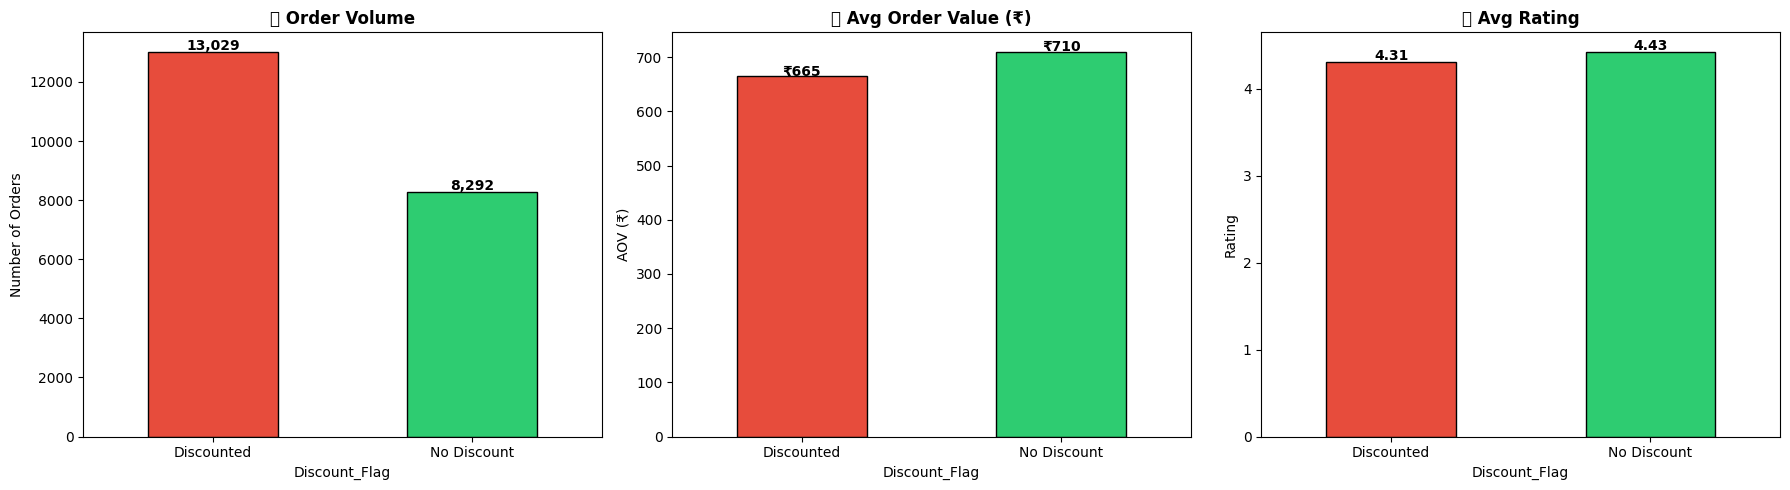


📊 DISCOUNT TYPE BREAKDOWN
        Discount Type  Orders
0      Promo Discount   11059
1  Flat offs/Freebies    1848
2       Gold Discount      28
3          Brand Pack     870


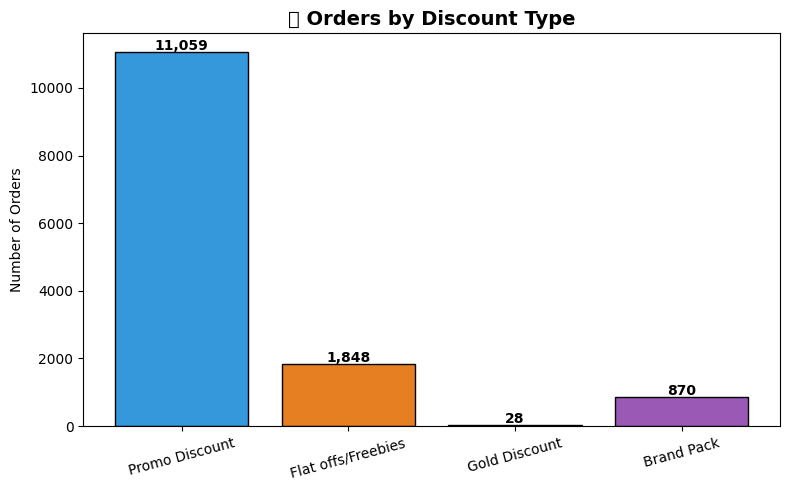


📊 DISCOUNT BUCKET-WISE PERFORMANCE
                 Orders  Avg_Revenue  Avg_Rating
Discount_Bucket                                 
0%                 8292       710.35        4.43
1-5%                 28      2637.54        5.00
5-10%               924      1056.44        4.14
10-20%             6698       801.29        4.33
20-50%             5338       418.02        4.30
50%+                 41       376.37        4.75


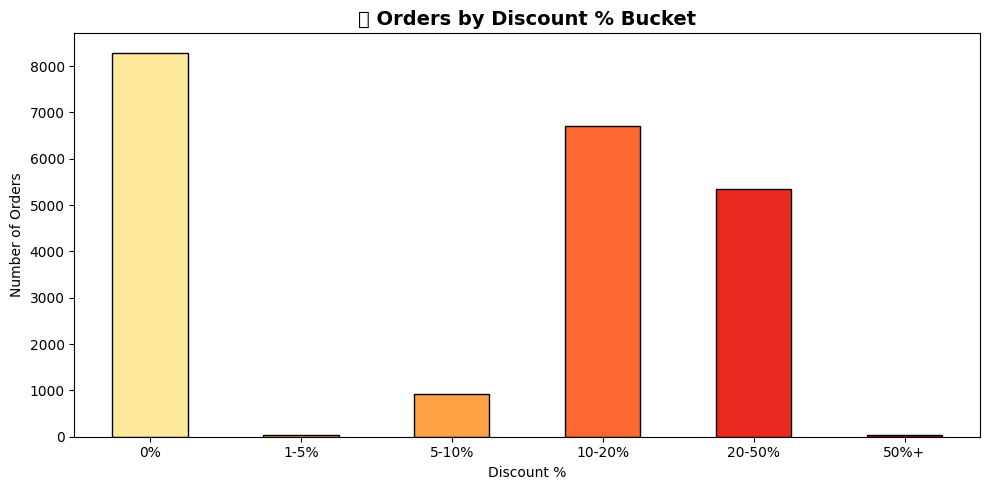

In [ ]:
# ============================
# 2. DISCOUNT & CAMPAIGN EFFECTIVENESS
# ============================

df['Discount_Flag'] = df['Total_Discount'].apply(lambda x: 'Discounted' if x > 0 else 'No Discount')

discount_analysis = df.groupby('Discount_Flag').agg(
    Order_Count = ('Order ID', 'count'),
    Avg_Order_Value = ('Total', 'mean'),
    Avg_Bill_Subtotal = ('Bill subtotal', 'mean'),
    Avg_Rating = ('Rating', 'mean'),
    Total_Revenue = ('Total', 'sum'),
    Avg_Discount = ('Total_Discount', 'mean')
).round(2)

print("="*60)
print("🏷️ DISCOUNT IMPACT ANALYSIS")
print("="*60)
print(discount_analysis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Order Count
discount_analysis['Order_Count'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('📦 Order Volume', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(discount_analysis['Order_Count']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# AOV
discount_analysis['Avg_Order_Value'].plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('💰 Avg Order Value (₹)', fontweight='bold')
axes[1].set_ylabel('AOV (₹)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(discount_analysis['Avg_Order_Value']):
    axes[1].text(i, v + 1, f'₹{v:.0f}', ha='center', fontweight='bold')

# Rating
discount_analysis['Avg_Rating'].plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('⭐ Avg Rating', fontweight='bold')
axes[2].set_ylabel('Rating')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for i, v in enumerate(discount_analysis['Avg_Rating']):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('discount_impact_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Discount Type Breakdown ----
print("\n" + "="*60)
print("📊 DISCOUNT TYPE BREAKDOWN")
print("="*60)

discount_types = {
    'Promo Discount': df['Restaurant discount (Promo)'].fillna(0).gt(0).sum(),
    'Flat offs/Freebies': df['Restaurant discount (Flat offs, Freebies & others)'].fillna(0).gt(0).sum(),
    'Gold Discount': df['Gold discount'].fillna(0).gt(0).sum(),
    'Brand Pack': df['Brand pack discount'].fillna(0).gt(0).sum()
}

discount_type_df = pd.DataFrame(list(discount_types.items()), columns=['Discount Type', 'Orders'])
print(discount_type_df)

plt.figure(figsize=(8, 5))
plt.bar(discount_type_df['Discount Type'], discount_type_df['Orders'],
        color=['#3498db', '#e67e22', '#f1c40f', '#9b59b6'], edgecolor='black')
plt.title('🏷️ Orders by Discount Type', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
for i, v in enumerate(discount_type_df['Orders']):
    plt.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('discount_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Discount % Buckets ----
df['Discount_Pct'] = (df['Total_Discount'] / df['Bill subtotal'] * 100).round(1)
df['Discount_Bucket'] = pd.cut(df['Discount_Pct'], bins=[-1, 0, 5, 10, 20, 50, 100],
                                labels=['0%', '1-5%', '5-10%', '10-20%', '20-50%', '50%+'])

bucket_analysis = df.groupby('Discount_Bucket').agg(
    Orders = ('Order ID', 'count'),
    Avg_Revenue = ('Total', 'mean'),
    Avg_Rating = ('Rating', 'mean')
).round(2)

print("\n" + "="*60)
print("📊 DISCOUNT BUCKET-WISE PERFORMANCE")
print("="*60)
print(bucket_analysis)

plt.figure(figsize=(10, 5))
bucket_analysis['Orders'].plot(kind='bar', color=sns.color_palette("YlOrRd", len(bucket_analysis)), edgecolor='black')
plt.title('📊 Orders by Discount % Bucket', fontsize=14, fontweight='bold')
plt.xlabel('Discount %')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('discount_buckets.png', dpi=150, bbox_inches='tight')
plt.show()

🏷️ DISCOUNT IMPACT ANALYSIS
               Order_Count  Avg_Order_Value  Avg_Bill_Subtotal  Avg_Rating  \
Discount_Flag                                                                
Discounted           13029           664.97             796.96        4.31   
No Discount           8292           710.35             676.41        4.43   

               Total_Revenue  Avg_Discount  
Discount_Flag                               
Discounted        8663843.87        163.68  
No Discount       5890214.27          0.00  


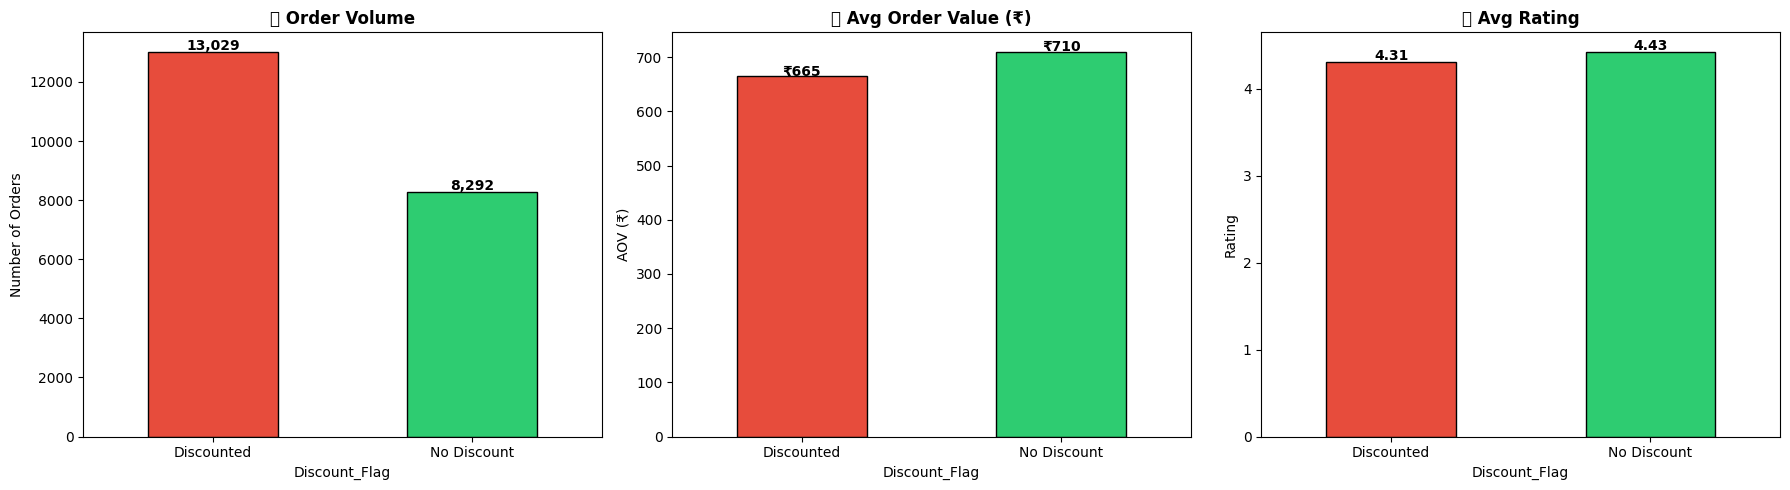


📊 DISCOUNT TYPE BREAKDOWN
        Discount Type  Orders
0      Promo Discount   11059
1  Flat offs/Freebies    1848
2       Gold Discount      28
3          Brand Pack     870


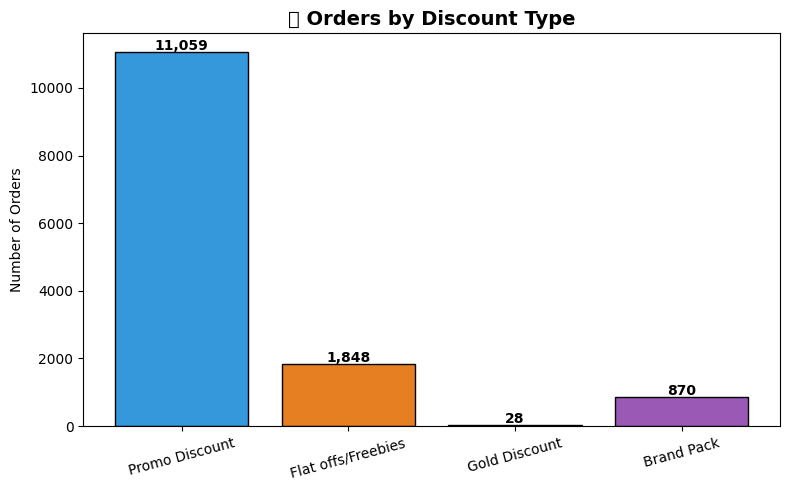


📊 DISCOUNT BUCKET-WISE PERFORMANCE
                 Orders  Avg_Revenue  Avg_Rating
Discount_Bucket                                 
0%                 8292       710.35        4.43
1-5%                 28      2637.54        5.00
5-10%               924      1056.44        4.14
10-20%             6698       801.29        4.33
20-50%             5338       418.02        4.30
50%+                 41       376.37        4.75


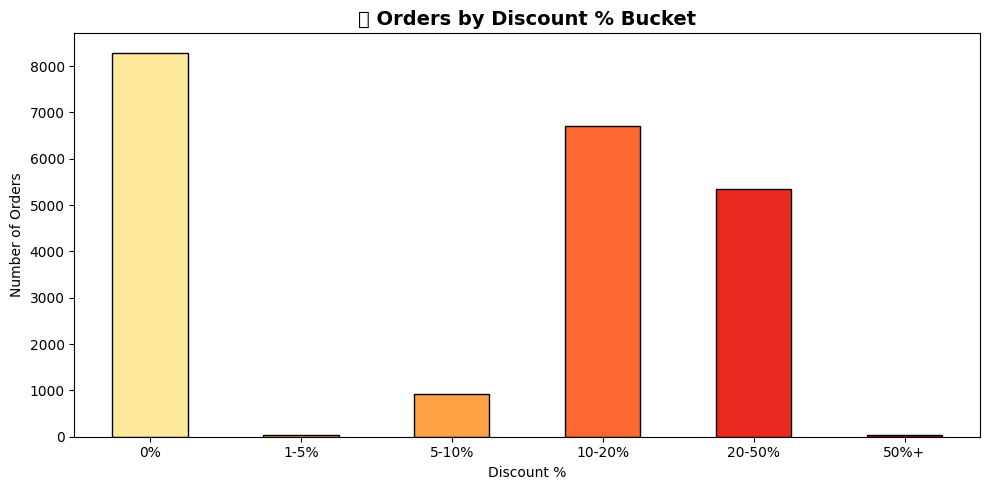

In [ ]:
# ============================
# 2. DISCOUNT & CAMPAIGN EFFECTIVENESS
# ============================

df['Discount_Flag'] = df['Total_Discount'].apply(lambda x: 'Discounted' if x > 0 else 'No Discount')

discount_analysis = df.groupby('Discount_Flag').agg(
    Order_Count = ('Order ID', 'count'),
    Avg_Order_Value = ('Total', 'mean'),
    Avg_Bill_Subtotal = ('Bill subtotal', 'mean'),
    Avg_Rating = ('Rating', 'mean'),
    Total_Revenue = ('Total', 'sum'),
    Avg_Discount = ('Total_Discount', 'mean')
).round(2)

print("="*60)
print("🏷️ DISCOUNT IMPACT ANALYSIS")
print("="*60)
print(discount_analysis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Order Count
discount_analysis['Order_Count'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('📦 Order Volume', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(discount_analysis['Order_Count']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# AOV
discount_analysis['Avg_Order_Value'].plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('💰 Avg Order Value (₹)', fontweight='bold')
axes[1].set_ylabel('AOV (₹)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(discount_analysis['Avg_Order_Value']):
    axes[1].text(i, v + 1, f'₹{v:.0f}', ha='center', fontweight='bold')

# Rating
discount_analysis['Avg_Rating'].plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('⭐ Avg Rating', fontweight='bold')
axes[2].set_ylabel('Rating')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for i, v in enumerate(discount_analysis['Avg_Rating']):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('discount_impact_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Discount Type Breakdown ----
print("\n" + "="*60)
print("📊 DISCOUNT TYPE BREAKDOWN")
print("="*60)

discount_types = {
    'Promo Discount': df['Restaurant discount (Promo)'].fillna(0).gt(0).sum(),
    'Flat offs/Freebies': df['Restaurant discount (Flat offs, Freebies & others)'].fillna(0).gt(0).sum(),
    'Gold Discount': df['Gold discount'].fillna(0).gt(0).sum(),
    'Brand Pack': df['Brand pack discount'].fillna(0).gt(0).sum()
}

discount_type_df = pd.DataFrame(list(discount_types.items()), columns=['Discount Type', 'Orders'])
print(discount_type_df)

plt.figure(figsize=(8, 5))
plt.bar(discount_type_df['Discount Type'], discount_type_df['Orders'],
        color=['#3498db', '#e67e22', '#f1c40f', '#9b59b6'], edgecolor='black')
plt.title('🏷️ Orders by Discount Type', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
for i, v in enumerate(discount_type_df['Orders']):
    plt.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('discount_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Discount % Buckets ----
df['Discount_Pct'] = (df['Total_Discount'] / df['Bill subtotal'] * 100).round(1)
df['Discount_Bucket'] = pd.cut(df['Discount_Pct'], bins=[-1, 0, 5, 10, 20, 50, 100],
                                labels=['0%', '1-5%', '5-10%', '10-20%', '20-50%', '50%+'])

bucket_analysis = df.groupby('Discount_Bucket').agg(
    Orders = ('Order ID', 'count'),
    Avg_Revenue = ('Total', 'mean'),
    Avg_Rating = ('Rating', 'mean')
).round(2)

print("\n" + "="*60)
print("📊 DISCOUNT BUCKET-WISE PERFORMANCE")
print("="*60)
print(bucket_analysis)

plt.figure(figsize=(10, 5))
bucket_analysis['Orders'].plot(kind='bar', color=sns.color_palette("YlOrRd", len(bucket_analysis)), edgecolor='black')
plt.title('📊 Orders by Discount % Bucket', fontsize=14, fontweight='bold')
plt.xlabel('Discount %')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('discount_buckets.png', dpi=150, bbox_inches='tight')
plt.show()

🔄 ORDER FUNNEL ANALYSIS
             Status  Count  Percentage
0         Delivered  21131       99.11
1          Rejected    158        0.74
2          Returned     25        0.12
3  Return cancelled      3        0.01
4         Picked up      3        0.01
5         Timed out      1        0.00


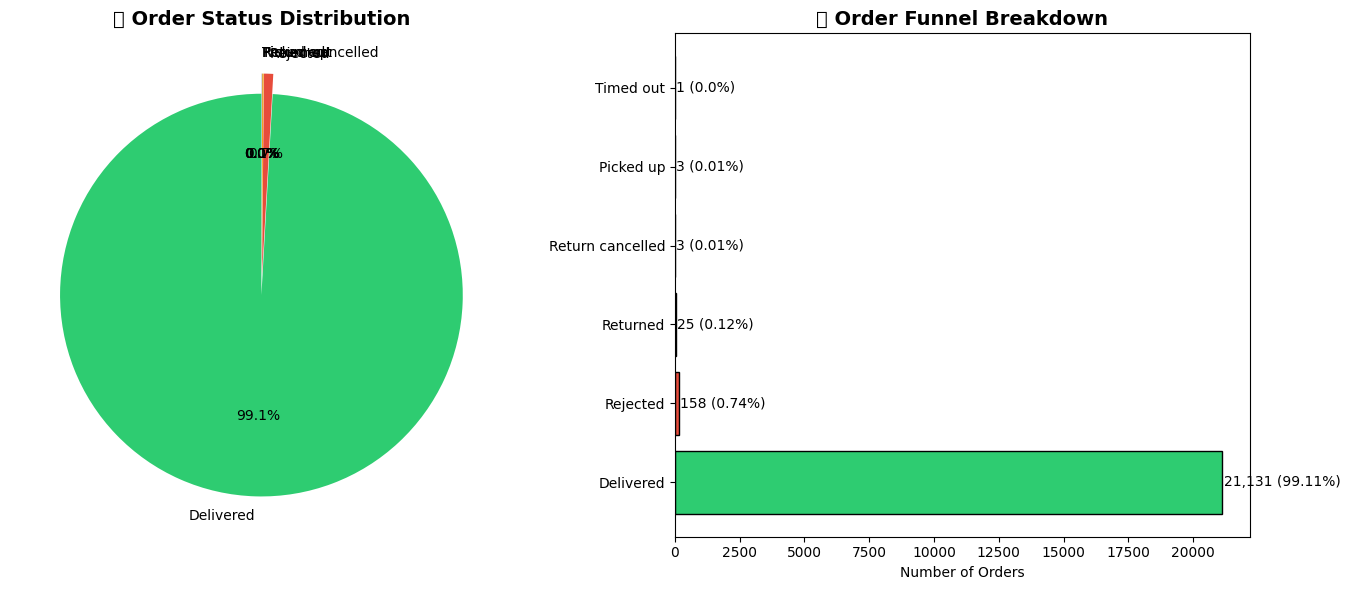


❌ TOP CANCELLATION / REJECTION REASONS
Cancellation / Rejection reason
Cancelled by Customer    89
Cancelled by Zomato      81
Merchant device issue    12
Kitchen is full           3
Items out of stock        1
Name: count, dtype: int64


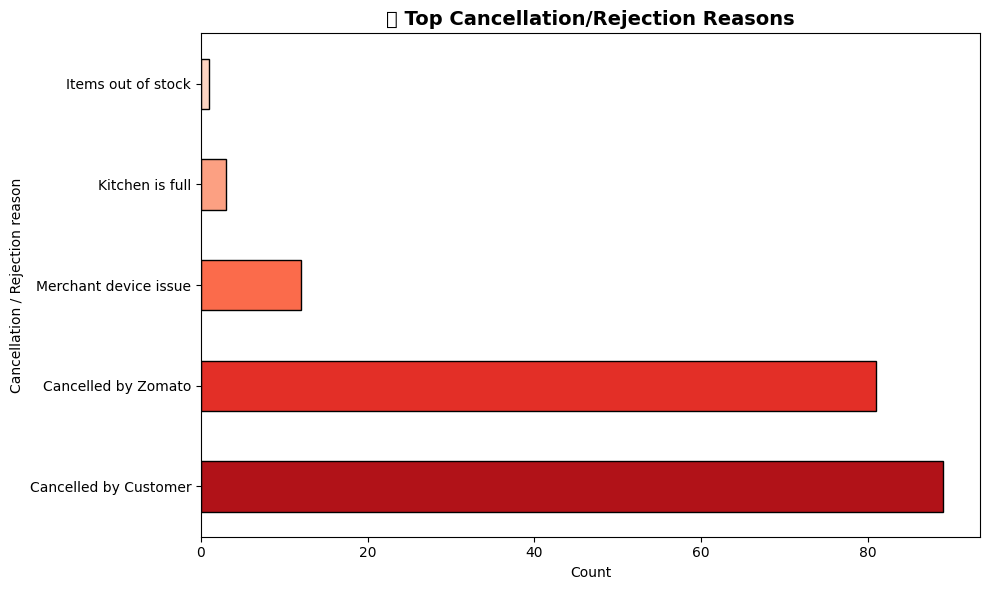


❌ TOP 15 RESTAURANTS BY CANCELLATION/REJECTION RATE (%)
Restaurant name
Masala Junction         3.57
Dilli Burger Adda       1.76
Tandoori Junction       1.30
Aura Pizzas             0.76
Swaad                   0.68
The Chicken Junction    0.00
dtype: float64


In [ ]:
# ============================
# 3. ORDER FUNNEL ANALYSIS
# ============================

funnel = df['Order Status'].value_counts()
funnel_df = funnel.reset_index()
funnel_df.columns = ['Status', 'Count']
funnel_df['Percentage'] = (funnel_df['Count'] / funnel_df['Count'].sum() * 100).round(2)

print("="*60)
print("🔄 ORDER FUNNEL ANALYSIS")
print("="*60)
print(funnel_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_pie = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c']

axes[0].pie(funnel_df['Count'], labels=funnel_df['Status'], autopct='%1.1f%%',
            colors=colors_pie[:len(funnel_df)], startangle=90, explode=[0.05]*len(funnel_df))
axes[0].set_title('📊 Order Status Distribution', fontsize=14, fontweight='bold')

axes[1].barh(funnel_df['Status'], funnel_df['Count'], color=colors_pie[:len(funnel_df)], edgecolor='black')
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('📊 Order Funnel Breakdown', fontsize=14, fontweight='bold')
for i, v in enumerate(funnel_df['Count']):
    axes[1].text(v + 50, i, f'{v:,} ({funnel_df["Percentage"].iloc[i]}%)', va='center')

plt.tight_layout()
plt.savefig('order_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Cancellation Reasons ----
cancel_df = df[df['Cancellation / Rejection reason'].notna()]
if len(cancel_df) > 0:
    cancel_reasons = cancel_df['Cancellation / Rejection reason'].value_counts().head(10)
    print("\n" + "="*60)
    print("❌ TOP CANCELLATION / REJECTION REASONS")
    print("="*60)
    print(cancel_reasons)

    plt.figure(figsize=(10, 6))
    cancel_reasons.plot(kind='barh', color=sns.color_palette("Reds_r", len(cancel_reasons)), edgecolor='black')
    plt.title('❌ Top Cancellation/Rejection Reasons', fontsize=14, fontweight='bold')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.savefig('cancellation_reasons.png', dpi=150, bbox_inches='tight')
    plt.show()

# ---- Restaurant-wise Cancellation Rate ----
cancel_rate = df.groupby('Restaurant name').apply(
    lambda x: (x['Order Status'].str.lower().str.contains('cancel|reject', na=False).sum() / len(x) * 100)
).round(2).sort_values(ascending=False).head(15)

print("\n" + "="*60)
print("❌ TOP 15 RESTAURANTS BY CANCELLATION/REJECTION RATE (%)")
print("="*60)
print(cancel_rate)

📅 MONTHLY REVENUE TREND
       Total_Revenue  Total_Orders     AOV
Month                                     
1         2812918.96          4011  701.30
9         2621548.58          4241  618.14
10        3012920.23          4277  704.45
11        3016541.46          4491  671.69
12        3090128.91          4301  718.47


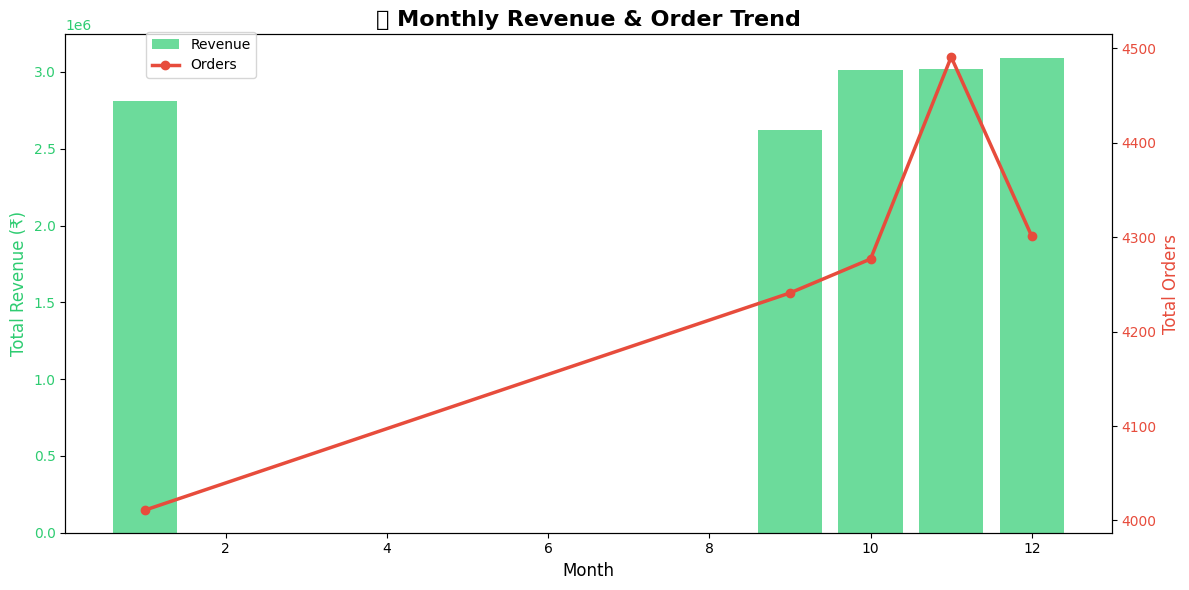


📅 DAY-WISE PERFORMANCE
           Orders     Revenue     AOV
Day                                  
Monday       2196  1403329.51  639.04
Tuesday      2885  1951583.29  676.46
Wednesday    3077  2022862.92  657.41
Thursday     2879  1941240.09  674.28
Friday       3403  2337614.35  686.93
Saturday     3923  2772889.68  706.83
Sunday       2958  2124538.30  718.23


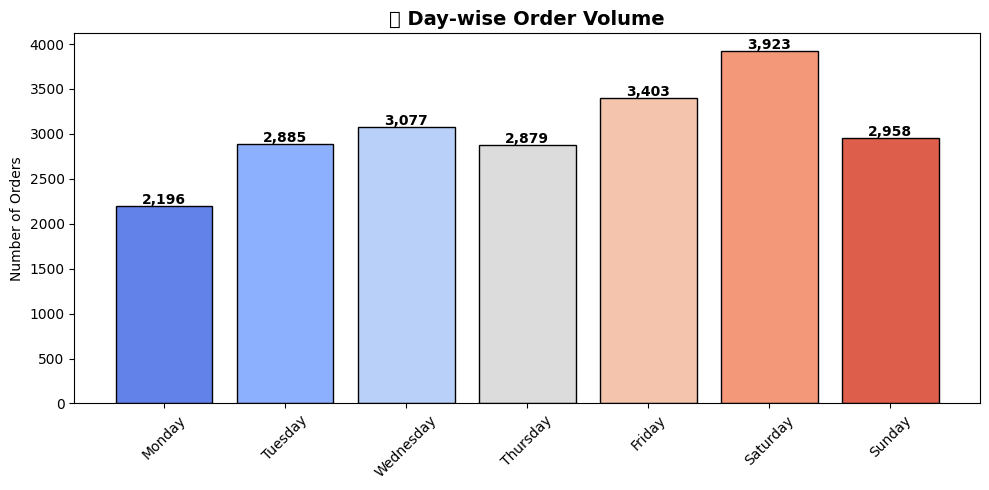

In [15]:
# ============================
# 4. MONTHLY & DAILY REVENUE TRENDS
# ============================

monthly_revenue = df.groupby('Month').agg(
    Total_Revenue = ('Total', 'sum'),
    Total_Orders = ('Order ID', 'count'),
    AOV = ('Total', 'mean')
).round(2)

print("="*60)
print("📅 MONTHLY REVENUE TREND")
print("="*60)
print(monthly_revenue)

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#2ecc71'
ax1.bar(monthly_revenue.index, monthly_revenue['Total_Revenue'], color=color1, alpha=0.7, label='Revenue')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue (₹)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.plot(monthly_revenue.index, monthly_revenue['Total_Orders'], color=color2, marker='o', linewidth=2.5, label='Orders')
ax2.set_ylabel('Total Orders', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('📈 Monthly Revenue & Order Trend', fontsize=16, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Day-wise
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('Day').agg(
    Orders = ('Order ID', 'count'),
    Revenue = ('Total', 'sum'),
    AOV = ('Total', 'mean')
).reindex(day_order)

print("\n" + "="*60)
print("📅 DAY-WISE PERFORMANCE")
print("="*60)
print(daily.round(2))

plt.figure(figsize=(10, 5))
plt.bar(daily.index, daily['Orders'], color=sns.color_palette("coolwarm", 7), edgecolor='black')
plt.title('📅 Day-wise Order Volume', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
for i, v in enumerate(daily['Orders']):
    plt.text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('daily_orders.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 TOP 15 STORE PERFORMANCE SCORECARD
                      Total_Revenue  Total_Orders     AOV  Avg_Rating  Avg_KPT  Avg_Rider_Wait  Total_Discount  Avg_Packaging  Revenue_Rank  Rating_Rank  KPT_Rank
Restaurant name                                                                                                                                                   
Aura Pizzas             10751617.42         14548  739.04        4.32    17.08            4.94      1388175.36          35.19             1            5         3
Swaad                    3545521.86          6332  559.94        4.43    17.77            4.51       701242.84          26.67             2            4         4
Tandoori Junction         133665.95           154  867.96        4.65    21.26            6.18            0.00          49.13             3            3         6
Dilli Burger Adda         101709.62           227  448.06        4.18    19.41            5.09        40223.16          21.34             4         

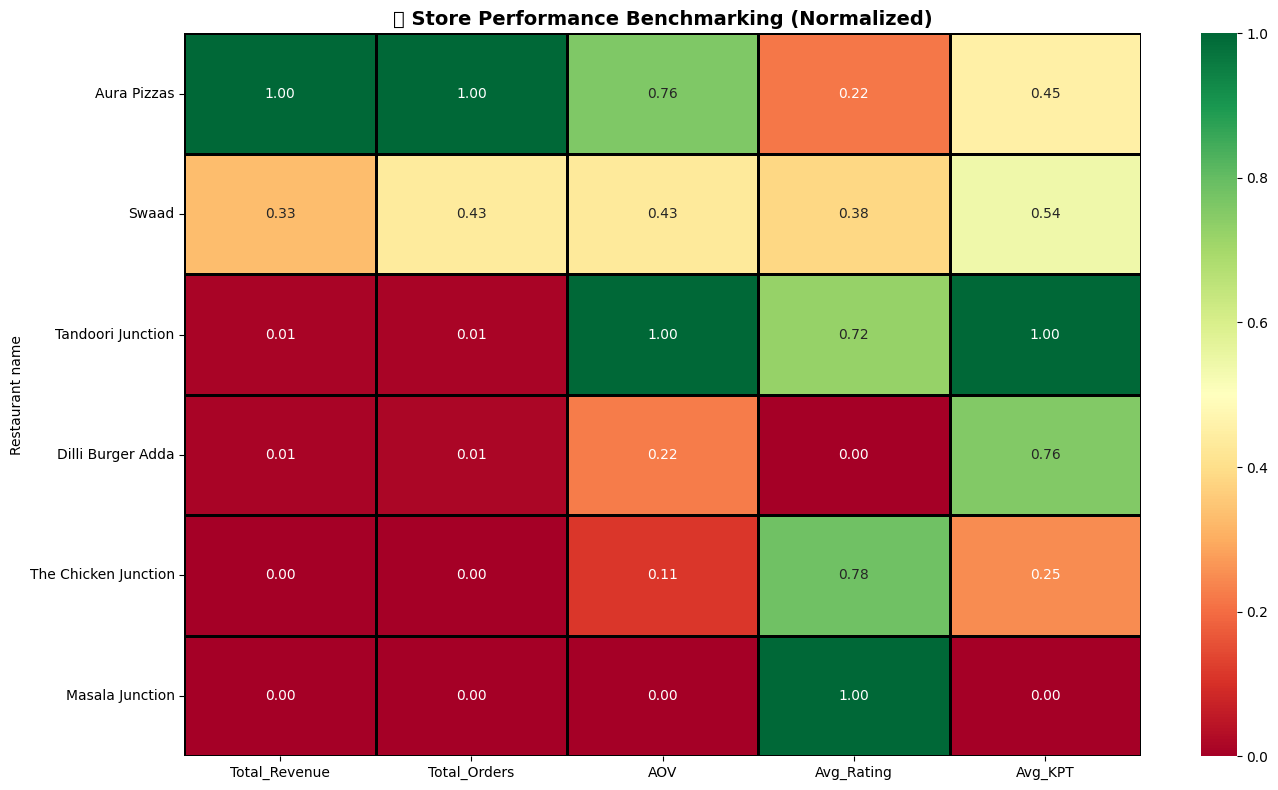

In [16]:
# ============================
# 5. STORE PERFORMANCE SCORECARD
# ============================

scorecard = df.groupby('Restaurant name').agg(
    Total_Revenue = ('Total', 'sum'),
    Total_Orders = ('Order ID', 'count'),
    AOV = ('Total', 'mean'),
    Avg_Rating = ('Rating', 'mean'),
    Avg_KPT = ('KPT duration (minutes)', 'mean'),
    Avg_Rider_Wait = ('Rider wait time (minutes)', 'mean'),
    Total_Discount = ('Total_Discount', 'sum'),
    Avg_Packaging = ('Packaging charges', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False).head(15)

scorecard['Revenue_Rank'] = scorecard['Total_Revenue'].rank(ascending=False).astype(int)
scorecard['Rating_Rank'] = scorecard['Avg_Rating'].rank(ascending=False).astype(int)
scorecard['KPT_Rank'] = scorecard['Avg_KPT'].rank(ascending=True).astype(int)

print("="*60)
print("🏆 TOP 15 STORE PERFORMANCE SCORECARD")
print("="*60)
print(scorecard.to_string())

# Heatmap
plt.figure(figsize=(14, 8))
scorecard_norm = scorecard[['Total_Revenue', 'Total_Orders', 'AOV', 'Avg_Rating', 'Avg_KPT']].copy()
for col in scorecard_norm.columns:
    scorecard_norm[col] = ((scorecard_norm[col] - scorecard_norm[col].min()) /
                           (scorecard_norm[col].max() - scorecard_norm[col].min()))

sns.heatmap(scorecard_norm, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=1, linecolor='black')
plt.title('🏆 Store Performance Benchmarking (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('store_benchmarking.png', dpi=150, bbox_inches='tight')
plt.show()

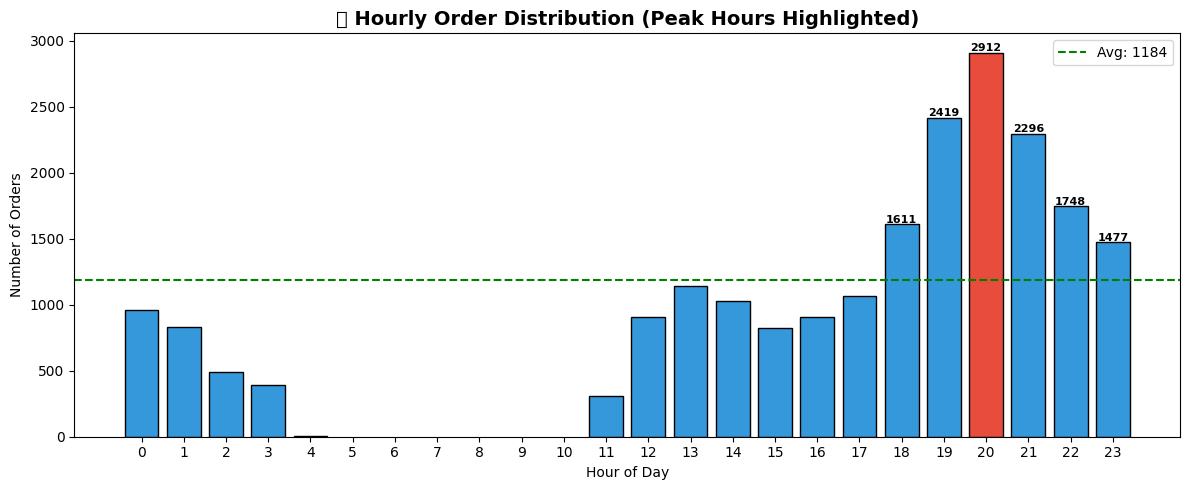

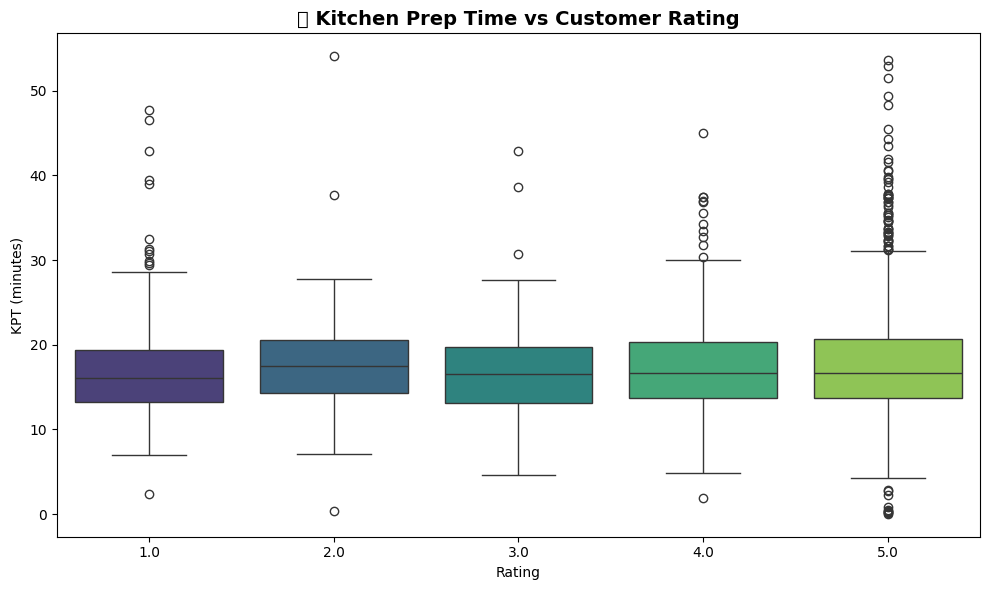

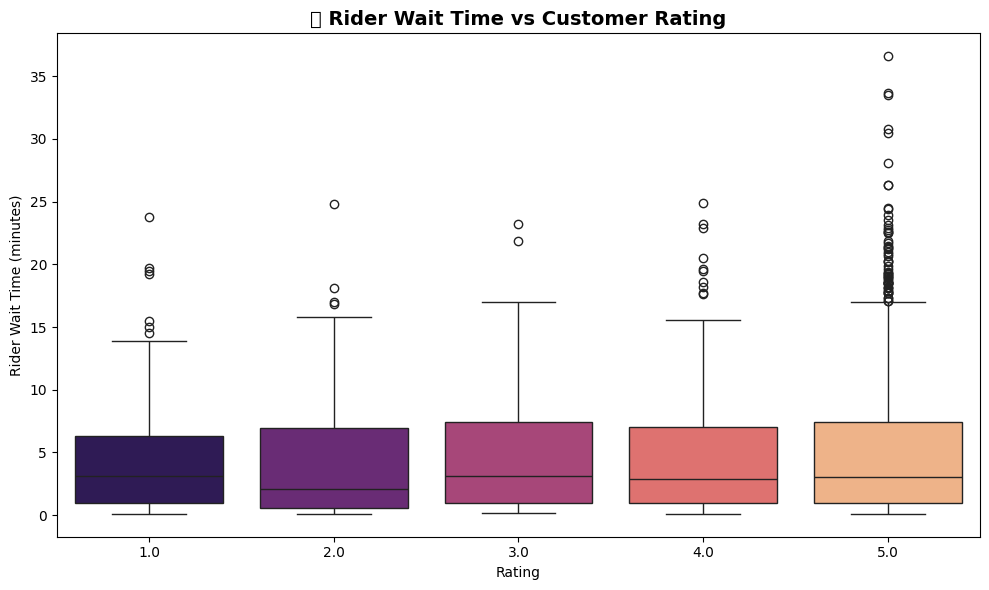

In [17]:
# ============================
# 6. PEAK HOURS & OPERATIONAL METRICS
# ============================

# Hourly
hourly = df.groupby('Hour')['Order ID'].count()

plt.figure(figsize=(12, 5))
colors_hr = ['#e74c3c' if v == hourly.max() else '#3498db' for v in hourly.values]
plt.bar(hourly.index, hourly.values, color=colors_hr, edgecolor='black')
plt.title('⏰ Hourly Order Distribution (Peak Hours Highlighted)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
for i, v in enumerate(hourly.values):
    if v > hourly.mean():
        plt.text(hourly.index[i], v + 10, f'{v}', ha='center', fontsize=8, fontweight='bold')
plt.axhline(y=hourly.mean(), color='green', linestyle='--', label=f'Avg: {hourly.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()

# KPT vs Rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Rating', y='KPT duration (minutes)', palette='viridis')
plt.title('⏱️ Kitchen Prep Time vs Customer Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('KPT (minutes)')
plt.tight_layout()
plt.savefig('kpt_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Rider Wait Time vs Rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Rating', y='Rider wait time (minutes)', palette='magma')
plt.title('🚴 Rider Wait Time vs Customer Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Rider Wait Time (minutes)')
plt.tight_layout()
plt.savefig('rider_wait_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

🌆 CITY-WISE PERFORMANCE
           Total_Revenue  Total_Orders     AOV  Avg_Rating
City                                                      
Delhi NCR    14554058.14         21321  682.62        4.36

📍 TOP 15 SUBZONES BY REVENUE
                         Total_Revenue  Total_Orders     AOV
Subzone                                                     
Greater Kailash 2 (GK2)     4756247.48          7380  644.48
Sector 4                    4494094.64          6530  688.22
DLF Phase 1                 2604429.60          3686  706.57
Sector 135                  1759093.61          2442  720.35
Vasant Kunj                  689695.79           920  749.67
Shahdara                     249106.40           360  691.96
Chittaranjan Park               949.62             2  474.81
Sikandarpur                     441.00             1  441.00


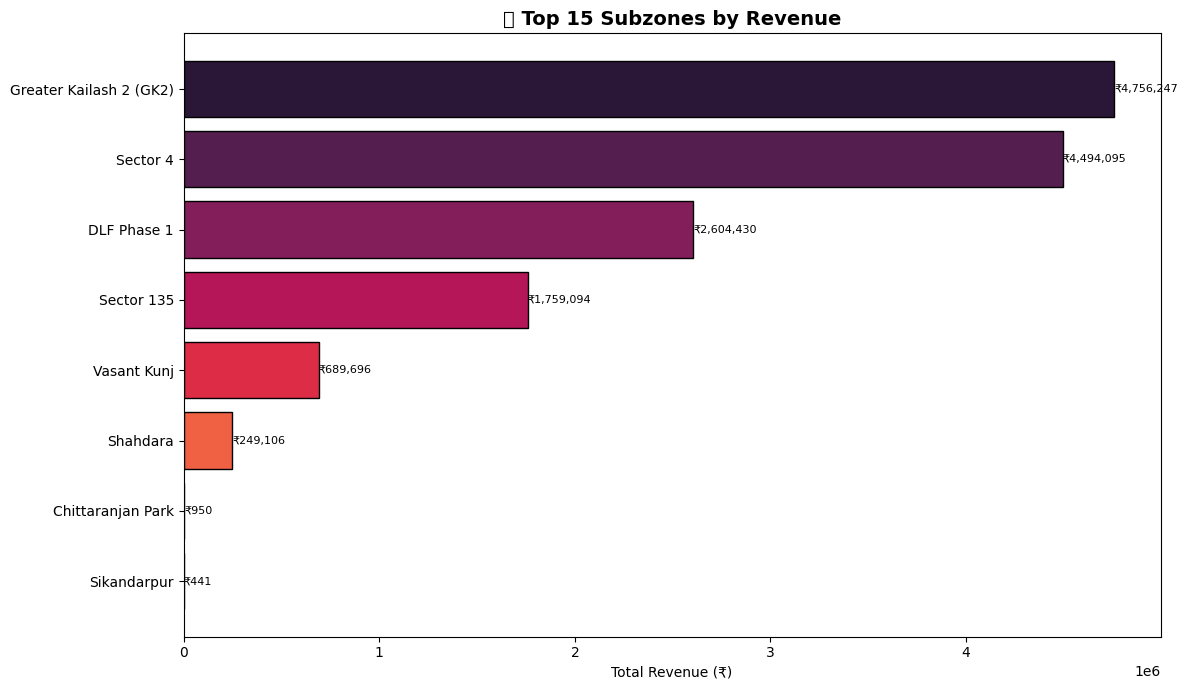

In [18]:
# ============================
# 7. CITY & SUBZONE PERFORMANCE
# ============================

city_perf = df.groupby('City').agg(
    Total_Revenue = ('Total', 'sum'),
    Total_Orders = ('Order ID', 'count'),
    AOV = ('Total', 'mean'),
    Avg_Rating = ('Rating', 'mean')
).sort_values('Total_Revenue', ascending=False).round(2)

print("="*60)
print("🌆 CITY-WISE PERFORMANCE")
print("="*60)
print(city_perf)

# Top Subzones
subzone_perf = df.groupby('Subzone').agg(
    Total_Revenue = ('Total', 'sum'),
    Total_Orders = ('Order ID', 'count'),
    AOV = ('Total', 'mean')
).sort_values('Total_Revenue', ascending=False).head(15).round(2)

print("\n" + "="*60)
print("📍 TOP 15 SUBZONES BY REVENUE")
print("="*60)
print(subzone_perf)

plt.figure(figsize=(12, 7))
plt.barh(subzone_perf.index, subzone_perf['Total_Revenue'],
         color=sns.color_palette("rocket", len(subzone_perf)), edgecolor='black')
plt.title('📍 Top 15 Subzones by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
for i, v in enumerate(subzone_perf['Total_Revenue']):
    plt.text(v + 100, i, f'₹{v:,.0f}', va='center', fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('subzone_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

Total orders with complaints: 469 (2.2%)

😤 TOP CUSTOMER COMPLAINTS
Customer complaint tag
Non-refunded complaint              157
Poor taste or quality               120
Poor packaging or spillage          104
Wrong item(s) delivered              48
Item(s) missing or not delivered     40
Name: count, dtype: int64


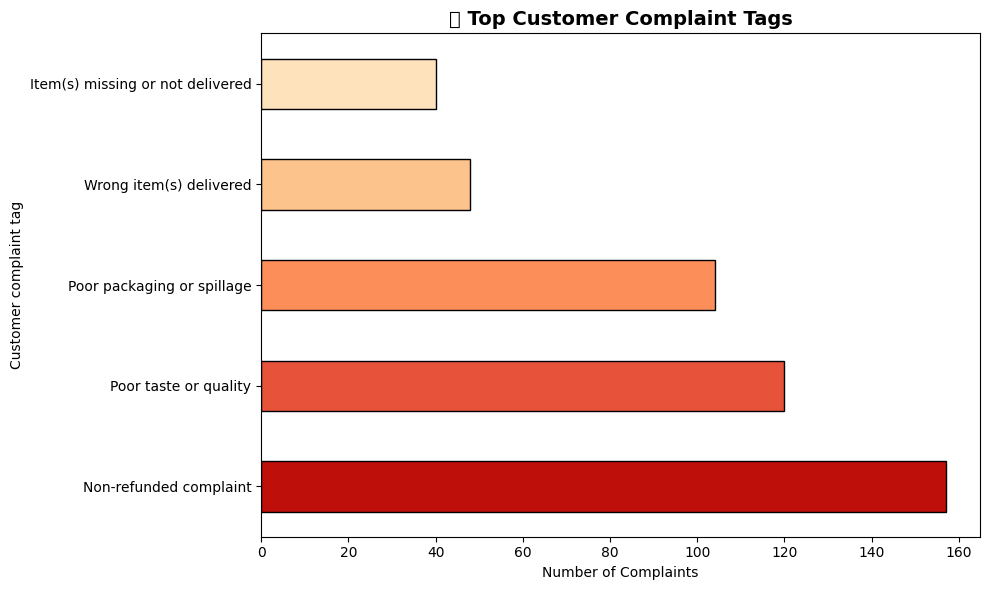

In [19]:
# ============================
# 8. CUSTOMER COMPLAINT ANALYSIS
# ============================

complaint_df = df[df['Customer complaint tag'].notna()]
print(f"Total orders with complaints: {len(complaint_df)} ({len(complaint_df)/len(df)*100:.1f}%)")

if len(complaint_df) > 0:
    complaints = complaint_df['Customer complaint tag'].value_counts().head(10)

    print("\n" + "="*60)
    print("😤 TOP CUSTOMER COMPLAINTS")
    print("="*60)
    print(complaints)

    plt.figure(figsize=(10, 6))
    complaints.plot(kind='barh', color=sns.color_palette("OrRd_r", len(complaints)), edgecolor='black')
    plt.title('😤 Top Customer Complaint Tags', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Complaints')
    plt.tight_layout()
    plt.savefig('customer_complaints.png', dpi=150, bbox_inches='tight')
    plt.show()

In [20]:
# ============================
# 📋 EXECUTIVE SUMMARY
# ============================

print("=" * 70)
print("📋 EXECUTIVE SUMMARY — FOOD DELIVERY REVENUE ANALYSIS")
print("=" * 70)

print(f"\n📊 Total Records Analyzed: {len(df):,}")
print(f"🏪 Total Restaurants: {df['Restaurant name'].nunique()}")
print(f"🌆 Total Cities: {df['City'].nunique()}")
print(f"📍 Total Subzones: {df['Subzone'].nunique()}")
print(f"💰 Total Revenue Generated: ₹{df['Total'].sum():,.2f}")
print(f"📦 Total Orders: {len(df):,}")
print(f"💵 Average Order Value (AOV): ₹{df['Total'].mean():,.2f}")
print(f"⭐ Overall Avg Rating: {df['Rating'].mean():.2f}")
print(f"⏱️ Avg Kitchen Prep Time (KPT): {df['KPT duration (minutes)'].mean():.1f} mins")
print(f"🚴 Avg Rider Wait Time: {df['Rider wait time (minutes)'].mean():.1f} mins")
print(f"🏷️ Total Discounts Given: ₹{df['Total_Discount'].sum():,.2f}")
print(f"❌ Complaint Rate: {df['Customer complaint tag'].notna().sum()/len(df)*100:.1f}%")

top_store = revenue_by_store.index[0]
print("\n" + "=" * 70)
print("🔑 KEY INSIGHTS")
print("=" * 70)
print(f"\n1. 🏆 Top Revenue Restaurant: {top_store}")
print(f"2. 💰 Discounted orders: {'Higher' if discount_analysis.loc['Discounted', 'Avg_Order_Value'] > discount_analysis.loc['No Discount', 'Avg_Order_Value'] else 'Lower'} AOV than non-discounted")
print(f"3. ⏰ Peak Ordering Hour: {hourly.idxmax()}:00 hrs ({hourly.max()} orders)")
print(f"4. 📅 Best Day: {daily['Orders'].idxmax()} ({daily['Orders'].max():,} orders)")
print(f"5. 📍 Top Subzone: {subzone_perf.index[0]}")

print("\n" + "=" * 70)
print("💡 ACTIONABLE RECOMMENDATIONS")
print("=" * 70)
print("""
1. 📣 Focus ad spends during peak hours to maximize campaign ROI
2. 🏷️ Optimize discount constructs — identify which discount type drives highest repeat orders
3. ❌ Reduce cancellation rate by addressing top cancellation reasons with restaurant partners
4. ⏱️ Improve KPT for low-rated stores — direct correlation with customer satisfaction
5. 📅 Run targeted campaigns on low-traffic days to balance weekly revenue
6. 📍 Expand operations in top-performing subzones; investigate underperforming ones
7. 😤 Address top customer complaints to improve retention and ratings
""")

📋 EXECUTIVE SUMMARY — FOOD DELIVERY REVENUE ANALYSIS

📊 Total Records Analyzed: 21,321
🏪 Total Restaurants: 6
🌆 Total Cities: 1
📍 Total Subzones: 8
💰 Total Revenue Generated: ₹14,554,058.14
📦 Total Orders: 21,321
💵 Average Order Value (AOV): ₹682.62
⭐ Overall Avg Rating: 4.36
⏱️ Avg Kitchen Prep Time (KPT): 17.3 mins
🚴 Avg Rider Wait Time: 4.8 mins
🏷️ Total Discounts Given: ₹2,132,639.97
❌ Complaint Rate: 2.2%

🔑 KEY INSIGHTS

1. 🏆 Top Revenue Restaurant: Aura Pizzas
2. 💰 Discounted orders: Lower AOV than non-discounted
3. ⏰ Peak Ordering Hour: 20:00 hrs (2912 orders)
4. 📅 Best Day: Saturday (3,923 orders)
5. 📍 Top Subzone: Greater Kailash 2 (GK2)

💡 ACTIONABLE RECOMMENDATIONS

1. 📣 Focus ad spends during peak hours to maximize campaign ROI
2. 🏷️ Optimize discount constructs — identify which discount type drives highest repeat orders
3. ❌ Reduce cancellation rate by addressing top cancellation reasons with restaurant partners
4. ⏱️ Improve KPT for low-rated stores — direct correlation 

In [21]:
from google.colab import files

images = [
    'store_revenue_analysis.png', 'discount_impact_analysis.png',
    'discount_type_breakdown.png', 'discount_buckets.png',
    'order_funnel.png', 'cancellation_reasons.png',
    'monthly_trend.png', 'daily_orders.png',
    'store_benchmarking.png', 'peak_hours.png',
    'kpt_vs_rating.png', 'rider_wait_vs_rating.png',
    'subzone_revenue.png', 'customer_complaints.png'
]

for f in images:
    try:
        files.download(f)
        print(f"✅ Downloaded: {f}")
    except:
        print(f"⚠️ Not found: {f}")

print("\n🎉 Done! All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: store_revenue_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: subzone_revenue.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: customer_complaints.png

🎉 Done! All charts downloaded!
